<a href="https://colab.research.google.com/github/ravichaudhary560/projects/blob/main/Movie_Sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
try:
    data = pd.read_csv('/content/IMDB Dataset.csv', engine='python', on_bad_lines='skip')
except Exception as e:
    print(f"Error reading CSV: {e}")

In [ ]:
data

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [ ]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
data.review[3]

"Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents are divorcing & arguing like in real life. And then we have Jake with his closet which totally ruins all the film! I expected to see a BOOGEYMAN similar movie, and instead i watched a drama with some meaningless thriller spots.<br /><br />3 out of 10 just for the well playing parents & descent dialogs. As for the shots with Jake: just ignore them."

In [ ]:
data.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [ ]:
data['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [ ]:
import re

def remove_tags(string):

    removelist = ""
    result = re.sub(r'<[^>]+>', '', string)

    result = re.sub(r'https?://\S+', '', result)

    result = re.sub(r'[^a-zA-Z0-9' + removelist + r'\s]', ' ', result)

    result = result.lower()

    return result


In [ ]:
data['review'] = data['review'].apply(remove_tags)

In [ ]:
import nltk

from nltk.tokenize import WhitespaceTokenizer

from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

nltk.download('omw-1.4')

w_tokenizer = WhitespaceTokenizer()

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

data['review'] = data['review'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop_words)]))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:

def lemmatize_text(text):

    lemmatized = [lemmatizer.lemmatize(w) for w in w_tokenizer.tokenize(text)]

    return ' '.join(lemmatized)

data['review'] = data['review'].apply(lemmatize_text)

In [ ]:
null_values = data.isnull().sum()

In [ ]:
null_values.index[0]

'review'

In [ ]:
print('There are {} missing values for {} and {} missing values for {}.'.format(null_values[0],
                                                                                null_values.index[0],
                                                                                null_values[1],
                                                                                null_values.index[1]))

There are 0 missing values for review and 0 missing values for sentiment.


/tmp/ipython-input-1794822848.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print('There are {} missing values for {} and {} missing values for {}.'.format(null_values[0],null_values.index[0],null_values[1],null_values.index[1]))


In [ ]:
num_duplicates = data.duplicated().sum()
print('There are {} duplicate reviews present in the dataset'.format(num_duplicates))

There are 426 duplicate reviews present in the dataset


In [ ]:
review = data['review']
duplicated_review = data[review.isin(review[review.duplicated()])].sort_values("review")
duplicated_review.head()

,review,sentiment
37655,1960 time change awakening people social uphea...,negative
4729,1960 time change awakening people social uphea...,negative
27754,1993 visitor enormous hit france sequence inev...,negative
2353,1993 visitor enormous hit france sequence inev...,negative
46976,1st watched 12 26 2008 dir eugene levy corny c...,negative


In [ ]:
data.drop_duplicates(inplace = True)

In [ ]:
print('The dataset contains {} rows and {} columns after removing duplicates'.format(data.shape[0],data.shape[1]))

The dataset contains 49574 rows and 2 columns after removing duplicates


In [ ]:
data.sentiment = [ 1 if each == "positive" else 0 for each in data.sentiment]

In [ ]:
data.head()

,review,sentiment
0,one reviewer mentioned watching 1 oz episode h...,1
1,wonderful little production filming technique ...,1
2,thought wonderful way spend time hot summer we...,1
3,basically family little boy jake think zombie ...,0
4,petter mattei love time money visually stunnin...,1


In [ ]:

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from bs4 import BeautifulSoup
import string,unicodedata

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix,ConfusionMatrixDisplay
from xgboost.sklearn import XGBClassifier

/tmp/ipython-input-4290494607.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data.sentiment,palette = ['green','red'],order = [1,0])


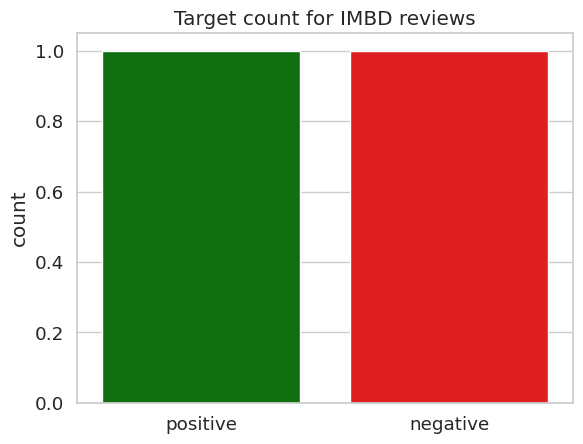

In [ ]:
sns.set(style = "whitegrid" , font_scale = 1.2)
sns.countplot(data.sentiment,palette = ['green','red'],
              order = [1,0])
plt.xticks(ticks = np.arange(2),
           labels = ['positive','negative'])
plt.title('Target count for IMBD reviews')
plt.show()

In [ ]:
print('Positive reviews are', (round(data['sentiment'].value_counts()[0])),
      'i.e.', round(data['sentiment'].value_counts()[0]/len(data) * 100,2),
      '% of the dataset')
print('Negative reviews are', (round(data['sentiment'].value_counts()[1])),
      'i.e.',round(data['sentiment'].value_counts()[1]/len(data) * 100,2),
      '% of the dataset')

Positive reviews are 24694 i.e. 49.81 % of the dataset
Negative reviews are 24880 i.e. 50.19 % of the dataset


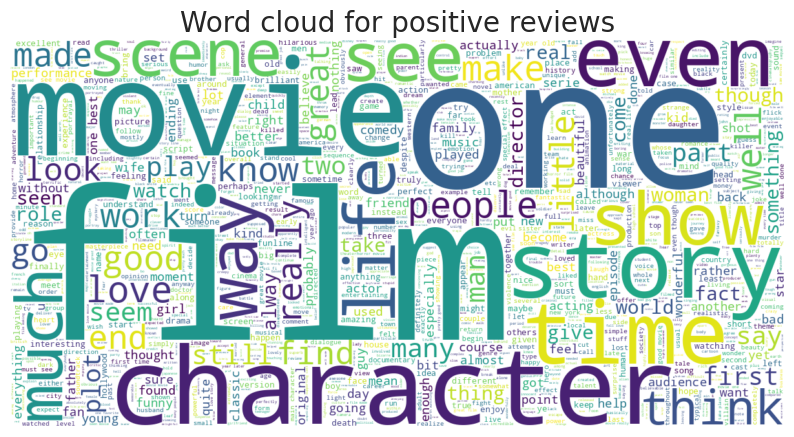

In [ ]:
positive_data = data[data.sentiment == 1]['review']
positive_data_string = ' '.join(positive_data)
plt.figure(figsize = (10,20))
wc = WordCloud(max_words = 2000, width=1200, height=600,background_color="white").generate(positive_data_string)
plt.imshow(wc , interpolation = 'bilinear')
plt.axis('off')
plt.title('Word cloud for positive reviews',fontsize = 20)
plt.show()

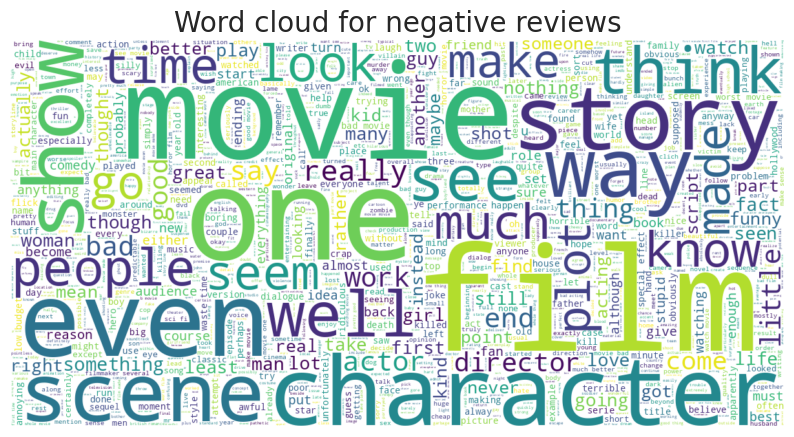

In [ ]:
negative_data = data[data.sentiment == 0]['review']
negative_data_string = ' '.join(negative_data)
plt.figure(figsize = (10,20))
wc = WordCloud(max_words = 2000, width=1200, height=600,background_color="white").generate(negative_data_string)
plt.imshow(wc , interpolation = 'bilinear')
plt.axis('off')
plt.title('Word cloud for negative reviews',fontsize = 20)
plt.show()

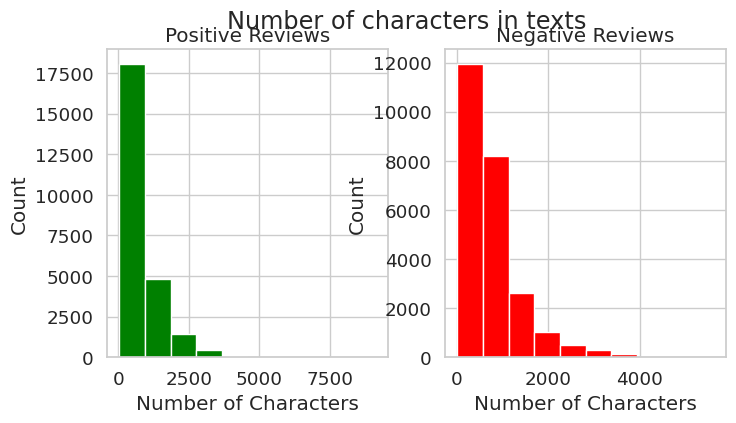

In [ ]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(8,4))
text_len=positive_data.str.len()
ax1.hist(text_len,color='green')
ax1.set_title('Positive Reviews')
ax1.set_xlabel('Number of Characters')
ax1.set_ylabel('Count')
text_len=negative_data.str.len()
ax2.hist(text_len,color='red')
ax2.set_title('Negative Reviews')
ax2.set_xlabel('Number of Characters')
ax2.set_ylabel('Count')
fig.suptitle('Number of characters in texts')
plt.show()

In [ ]:
def get_ngrams(review, n, g):
    vec = CountVectorizer(ngram_range=(g, g)).fit(review)
    bag_of_words = vec.transform(review)
    sum_words = bag_of_words.sum(axis=0)
    sum_words = np.array(sum_words)[0].tolist()
    words_freq = [(word, sum_words[idx]) for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

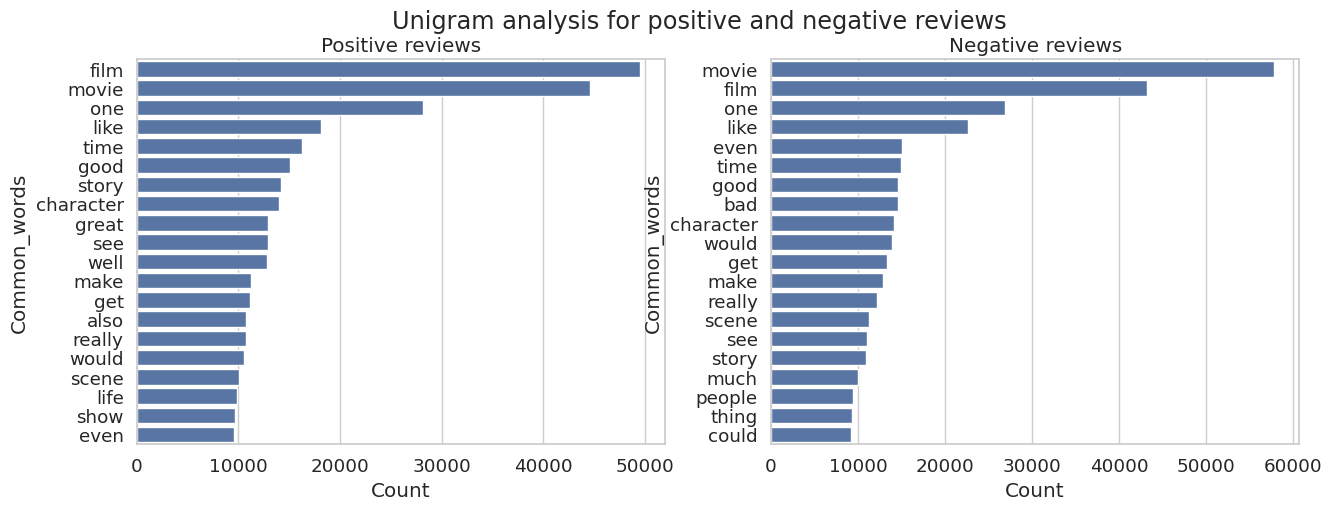

In [ ]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,5))
uni_positive = get_ngrams(positive_data,20,1)
uni_positive = dict(uni_positive)
temp = pd.DataFrame(list(uni_positive.items()), columns = ["Common_words" , 'Count'])
sns.barplot(data = temp, x="Count", y="Common_words", orient='h',ax = ax1)
ax1.set_title('Positive reviews')
uni_negative = get_ngrams(negative_data,20,1)
uni_negative = dict(uni_negative)
temp = pd.DataFrame(list(uni_negative.items()), columns = ["Common_words" , 'Count'])
sns.barplot(data = temp, x="Count", y="Common_words", orient='h',ax = ax2)
ax2.set_title('Negative reviews')
fig.suptitle('Unigram analysis for positive and negative reviews')
plt.show()

In [ ]:
train, test= train_test_split(data, test_size=0.2, random_state=42)
Xtrain, ytrain = train['review'], train['sentiment']
Xtest, ytest = test['review'], test['sentiment']

In [ ]:
tfidf_vect = TfidfVectorizer()
Xtrain_tfidf = tfidf_vect.fit_transform(Xtrain)
Xtest_tfidf = tfidf_vect.transform(Xtest)


count_vect = CountVectorizer()
Xtrain_count = count_vect.fit_transform(Xtrain)
Xtest_count = count_vect.transform(Xtest)

Logistic Regression Accuracy : 89.38%


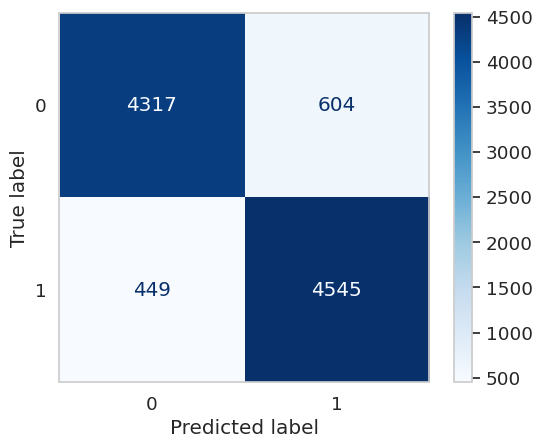

In [ ]:
lr = LogisticRegression()
lr.fit(Xtrain_tfidf,ytrain)
p1=lr.predict(Xtest_tfidf)
s1=accuracy_score(ytest,p1)
print("Logistic Regression Accuracy :", "{:.2f}%".format(100*s1))
ConfusionMatrixDisplay.from_estimator(lr, Xtest_tfidf, ytest,cmap = 'Blues')
plt.grid(False)
plt.show()

Multinomial Naive Bayes Classifier Accuracy : 86.49%


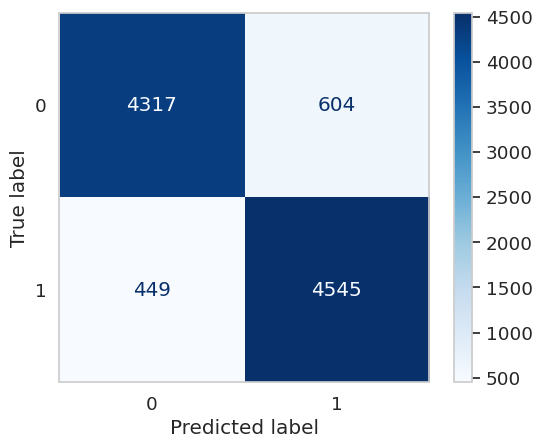

In [ ]:
mnb= MultinomialNB()
mnb.fit(Xtrain_tfidf,ytrain)
p2=mnb.predict(Xtest_tfidf)
s2=accuracy_score(ytest,p2)
print("Multinomial Naive Bayes Classifier Accuracy :", "{:.2f}%".format(100*s2))
ConfusionMatrixDisplay.from_estimator(lr, Xtest_tfidf, ytest,cmap = 'Blues')
plt.grid(False)

Linear Support Vector Classifier Accuracy : 89.82%


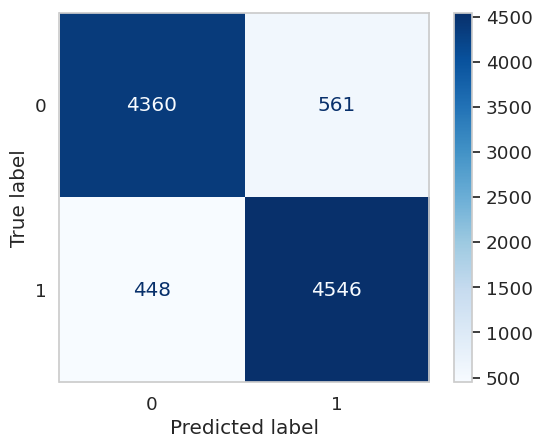

In [ ]:
linear_svc = LinearSVC(penalty='l2',loss = 'hinge')
linear_svc.fit(Xtrain_tfidf,ytrain)
p3=linear_svc.predict(Xtest_tfidf)
s3=accuracy_score(ytest,p3)
print("Linear Support Vector Classifier Accuracy :", "{:.2f}%".format(100*s3))
ConfusionMatrixDisplay.from_estimator(linear_svc, Xtest_tfidf, ytest,cmap = 'Blues')
plt.grid(False)

XGBoost Accuracy : 85.27%


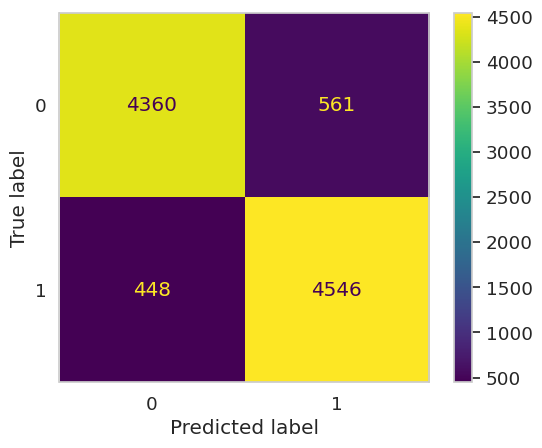

In [ ]:
xgbo = XGBClassifier()
xgbo.fit(Xtrain_tfidf,ytrain)
p4=xgbo.predict(Xtest_tfidf)
s4=accuracy_score(ytest,p4)
print("XGBoost Accuracy :", "{:.2f}%".format(100*s4))
ConfusionMatrixDisplay.from_estimator(linear_svc, Xtest_tfidf, ytest)
plt.grid(False)

In [ ]:
Model_Comparison_Table = pd.DataFrame(data = [accuracy_score(ytest, p1),
                                              accuracy_score(ytest, p2),
                                              accuracy_score(ytest, p3),
                                              accuracy_score(ytest, p4),
                                              ],

                                      index = ['Logistic Regression',"MultinomialNB",'SVM',
                                               'XGBoost'],

                                      columns = ['Accuracy'])

In [ ]:
Model_Comparison_Table['Accuracy'] = Model_Comparison_Table['Accuracy'].round(2)

In [ ]:
Model_Comparison_Table.sort_values(by=['Accuracy'],ascending=False)

,Accuracy
SVM,0.90
Logistic Regression,0.89
MultinomialNB,0.86
XGBoost,0.85
